# 2.2.1 Data Pre - processing.

Shape of X: (150, 5)
Shape of y: (150,)
Shape of y_encoded: (150, 3)
Iteration 0: Cost 0.9824
Iteration 100: Cost 0.2426
Iteration 200: Cost 0.1687
Iteration 300: Cost 0.1325
Iteration 400: Cost 0.1102
Iteration 500: Cost 0.0948
Iteration 600: Cost 0.0835
Iteration 700: Cost 0.0748
Iteration 800: Cost 0.0678
Iteration 900: Cost 0.0621


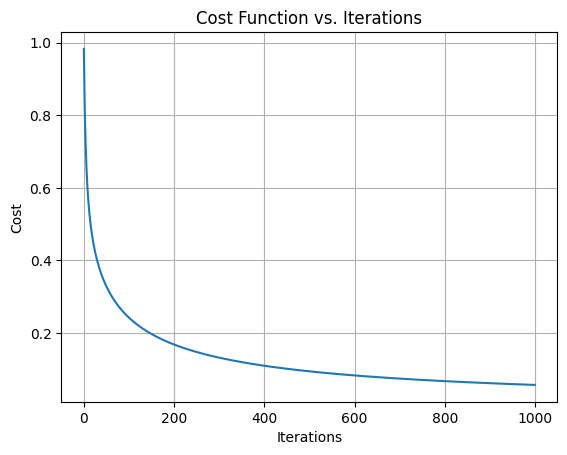


--- Final Model Results ---
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


In [8]:

# Slide 14: 2.2.1 Data Pre - processing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Iris dataset
df = pd.read_csv('Iris.csv')

# Separate features (X) and target labels (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")



# Slide 15: 2.2.1 Data Pre - processing

from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Reshape y to be a 2D array, as required by the encoder
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

print(f"Shape of y_encoded: {y_encoded.shape}")


# Slide 16: 2.2.1 Data Pre - processing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test = scaler.transform(X_test)



# Slide 18: 2.3.1 Implementations

def softmax(z):
    """
    Compute softmax values for each sets of scores in z.
    """
    # Subtracting the maximum value for numerical stability
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# Slide 20: 2.4.1 Implementations – Loss Function

def loss_softmax(y_pred, y):
    """
    Compute the categorical cross-entropy loss for a single sample.
    """
    epsilon = 1e-15 # To prevent log(0)
    loss = -np.sum(y * np.log(y_pred + epsilon))
    return loss



# Slide 21: 2.4.2 Implementations – Cost Function

def cost_softmax(X, y, W, b):
    """
    Compute the average categorical cross-entropy cost over all samples.
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    epsilon = 1e-15
    total_loss = -np.sum(y * np.log(y_pred + epsilon))
    return total_loss / n



# Slide 25: 2.6.1.1 Implementations – Computing Gradients

def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function w.r.t weights and biases.
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    # Gradients w.r.t W and b
    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum((y_pred - y), axis=0) / n

    return grad_W, grad_b



# Slide 26: 2.6.2 Implementing Gradient Descent

def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize weights and biases.
    """
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:.4f}")

    return W, b, cost_history



# Slide 27: 2.7 Implementing a Decision Function

def predict_softmax(X, W, b):
    """
    Predict class labels for samples in X.
    """
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return np.argmax(y_pred, axis=1)



# Slide 28: 2.8 Putting it all Together!!!

# Number of features and classes
d = X_train.shape[1]
c = y_train.shape[1]

# Initialize weights and biases
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Hyperparameters
alpha = 0.1
n_iter = 1000

# Train the model
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost=True)

# Plot cost history
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()


# Slide 31: 2.7.2 Implementations – Evaluation Function

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def evaluate_classification(y_true, y_pred):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute metrics
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1

# Final Evaluation Execution (Calling the function from Slide 31)
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1) # Convert one-hot back to 1D array for comparison
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\n--- Final Model Results ---")
print("Confusion Matrix:\n", cm)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")